# PRACTICA PARTE 1: Azure AI Search - Wizard Import Data

**Objetivo:** Documentar el pipeline de indexación mediante el wizard "Import data" del portal de Azure con vectorización integrada.

**Estudiante:** 
**Fecha:** 
**Recurso Azure AI Search:** 

---
## 1. Configuración inicial del wizard

### Pasos realizados:
1. ✅ Acceder a Azure AI Search → **Import data**
2. ✅ Escenario seleccionado: **RAG** (non-agentic retrieval)
3. ✅ Fuente de datos: **Azure Blob Storage**
4. ✅ Vectorización: **Azure OpenAI** (deployment de embeddings)

### Credenciales utilizadas:
- **Suscripción:** `[Tu suscripción]`
- **Contenedor Blob:** `[Nombre contenedor]`
- **Modelo embeddings:** `text-embedding-3-large` (o el que uses)

---

In [4]:
# Celda para cargar bibliotecas necesarias para mostrar imágenes
from IPython.display import Image, display
import os


## 2. ÍNDICE (Index Schema)

### Captura del esquema del índice creado:

**Ruta de la imagen:** `./screenshots/01_index_schema.png`

```
Ubicación en portal: Azure AI Search → Índices → [nombre del índice] → Definición JSON
```

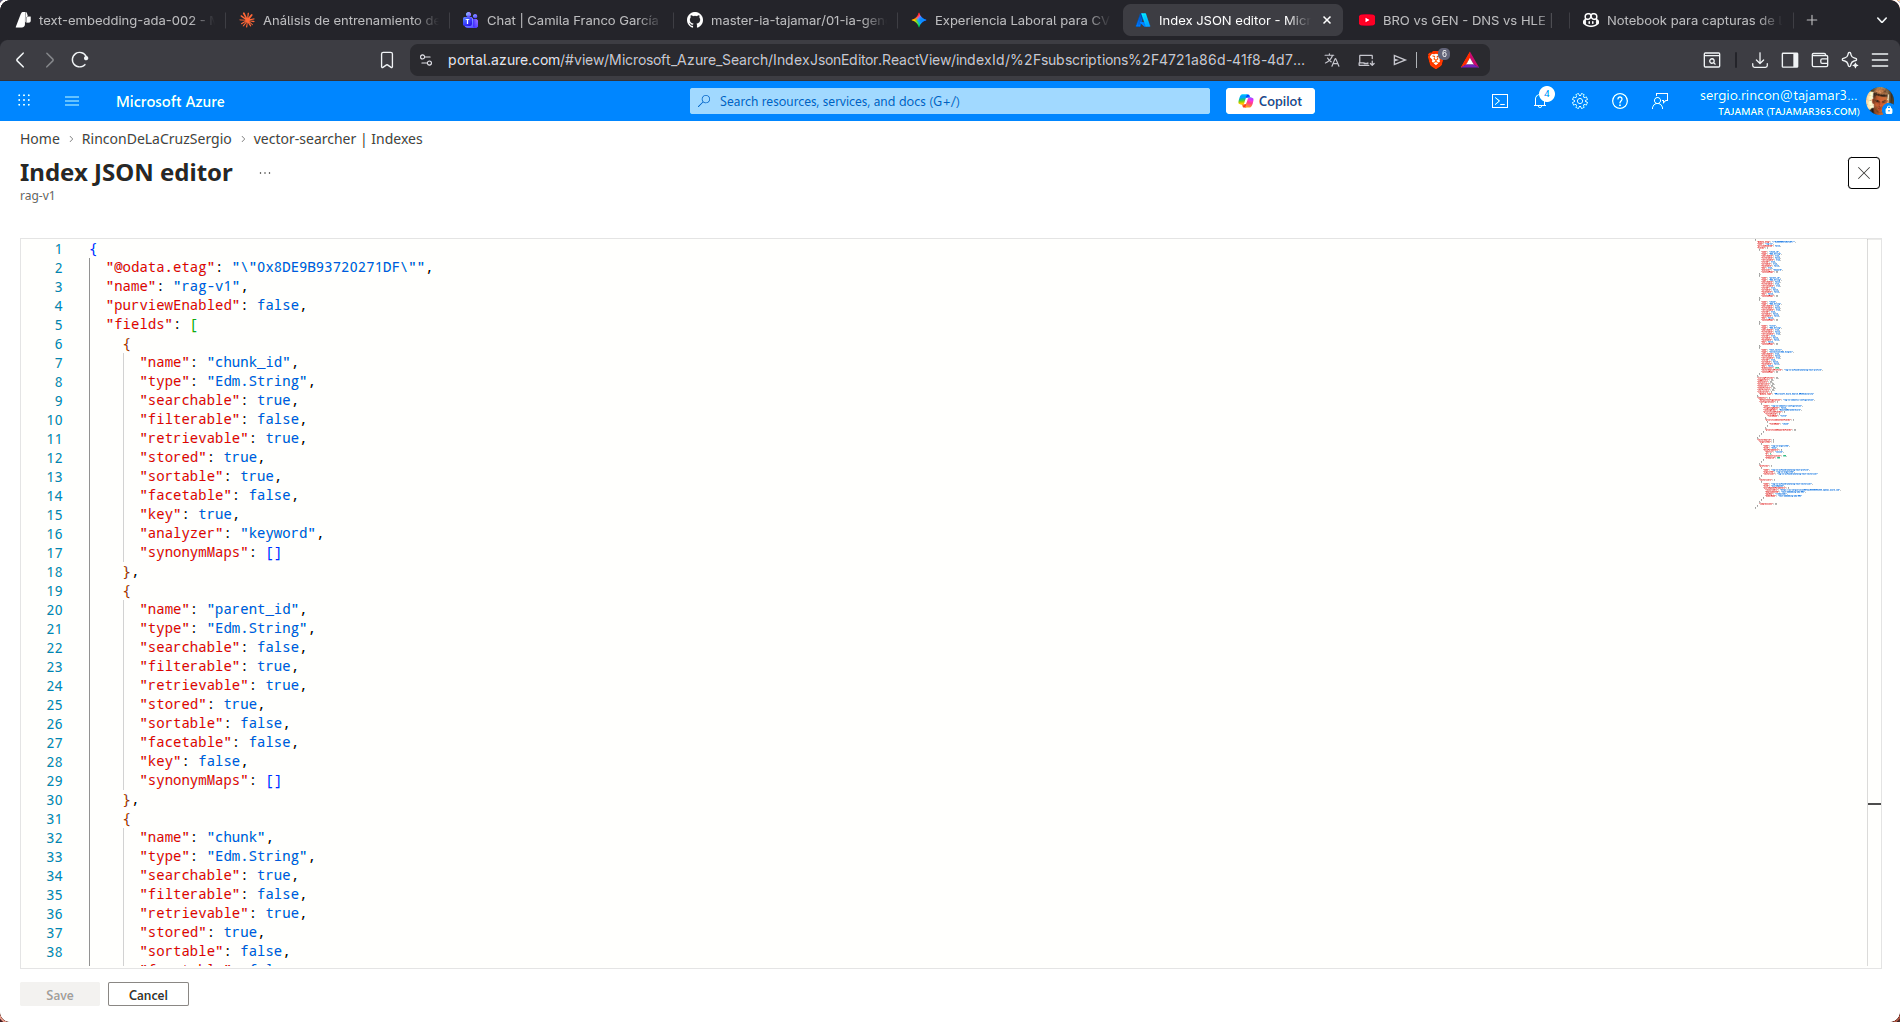

In [27]:


ruta_imagen = "./capturas/01_index_schema.png"  # ← MODIFICA ESTA RUTA

if os.path.exists(ruta_imagen):
    display(Image(filename=ruta_imagen))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### Explicación del esquema:

**Campos principales:**
- `id`: Identificador único del documento
- `content`: Contenido textual del documento
- `metadata_storage_path`: Ruta del documento en Blob Storage
- `text_vector`: Campo vectorial (embeddings generados por Azure OpenAI)
- `title`: Título del documento (si se extrajo)
- `created_date`: Fecha de creación

**Configuración de búsqueda:**
- ✅ Retrievable: Determina si el campo se devuelve en resultados
- ✅ Searchable: Permite búsqueda por texto en ese campo
- ✅ Filterable: Se puede usar en filtros
- ✅ Sortable: Se puede ordenar por este campo
- ✅ Facetable: Se puede usar en facetas

### Definición JSON completa del índice:

In [6]:
index_json = """
{
  "@odata.etag": "\"0x8DE9B93720271DF\"",
  "name": "rag-v1",
  "purviewEnabled": false,
  "fields": [
    {
      "name": "chunk_id",
      "type": "Edm.String",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": true,
      "facetable": false,
      "key": true,
      "analyzer": "keyword",
      "synonymMaps": []
    },
    {
      "name": "parent_id",
      "type": "Edm.String",
      "searchable": false,
      "filterable": true,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "synonymMaps": []
    },
    {
      "name": "chunk",
      "type": "Edm.String",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "synonymMaps": []
    },
    {
      "name": "title",
      "type": "Edm.String",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "synonymMaps": []
    },
    {
      "name": "text_vector",
      "type": "Collection(Edm.Single)",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "dimensions": 1536,
      "vectorSearchProfile": "rag-v1-aiFoundryCatalog-text-profile",
      "synonymMaps": []
    }
  ],
  "scoringProfiles": [],
  "suggesters": [],
  "analyzers": [],
  "normalizers": [],
  "tokenizers": [],
  "tokenFilters": [],
  "charFilters": [],
  "similarity": {
    "@odata.type": "#Microsoft.Azure.Search.BM25Similarity"
  },
  "semantic": {
    "defaultConfiguration": "rag-v1-semantic-configuration",
    "configurations": [
      {
        "name": "rag-v1-semantic-configuration",
        "flightingOptIn": false,
        "rankingOrder": "BoostedRerankerScore",
        "prioritizedFields": {
          "titleField": {
            "fieldName": "title"
          },
          "prioritizedContentFields": [
            {
              "fieldName": "chunk"
            }
          ],
          "prioritizedKeywordsFields": []
        }
      }
    ]
  },
  "vectorSearch": {
    "algorithms": [
      {
        "name": "rag-v1-algorithm",
        "kind": "hnsw",
        "hnswParameters": {
          "metric": "cosine",
          "m": 4,
          "efConstruction": 400,
          "efSearch": 500
        }
      }
    ],
    "profiles": [
      {
        "name": "rag-v1-aiFoundryCatalog-text-profile",
        "algorithm": "rag-v1-algorithm",
        "vectorizer": "rag-v1-aiFoundryCatalog-text-vectorizer"
      }
    ],
    "vectorizers": [
      {
        "name": "rag-v1-aiFoundryCatalog-text-vectorizer",
        "kind": "azureOpenAI",
        "azureOpenAIParameters": {
          "resourceUri": "https://ai-sergiorincon0872ai045504941434.openai.azure.com",
          "deploymentId": "text-embedding-ada-002",
          "apiKey": "<redacted>",
          "modelName": "text-embedding-ada-002"
        }
      }
    ],
    "compressions": []
  }
}
"""

print("📋 Definición JSON del índice:")
print(index_json)

📋 Definición JSON del índice:

{
  "@odata.etag": ""0x8DE9B93720271DF"",
  "name": "rag-v1",
  "purviewEnabled": false,
  "fields": [
    {
      "name": "chunk_id",
      "type": "Edm.String",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": true,
      "facetable": false,
      "key": true,
      "analyzer": "keyword",
      "synonymMaps": []
    },
    {
      "name": "parent_id",
      "type": "Edm.String",
      "searchable": false,
      "filterable": true,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "synonymMaps": []
    },
    {
      "name": "chunk",
      "type": "Edm.String",
      "searchable": true,
      "filterable": false,
      "retrievable": true,
      "stored": true,
      "sortable": false,
      "facetable": false,
      "key": false,
      "synonymMaps": []
    },
    {
      "name": "title",
      "type": "Edm.S

---
## 3. SEMANTIC CONFIGURATION

### Captura de la configuración semántica:

**Ruta de la imagen:** `./screenshots/02_semantic_config.png`

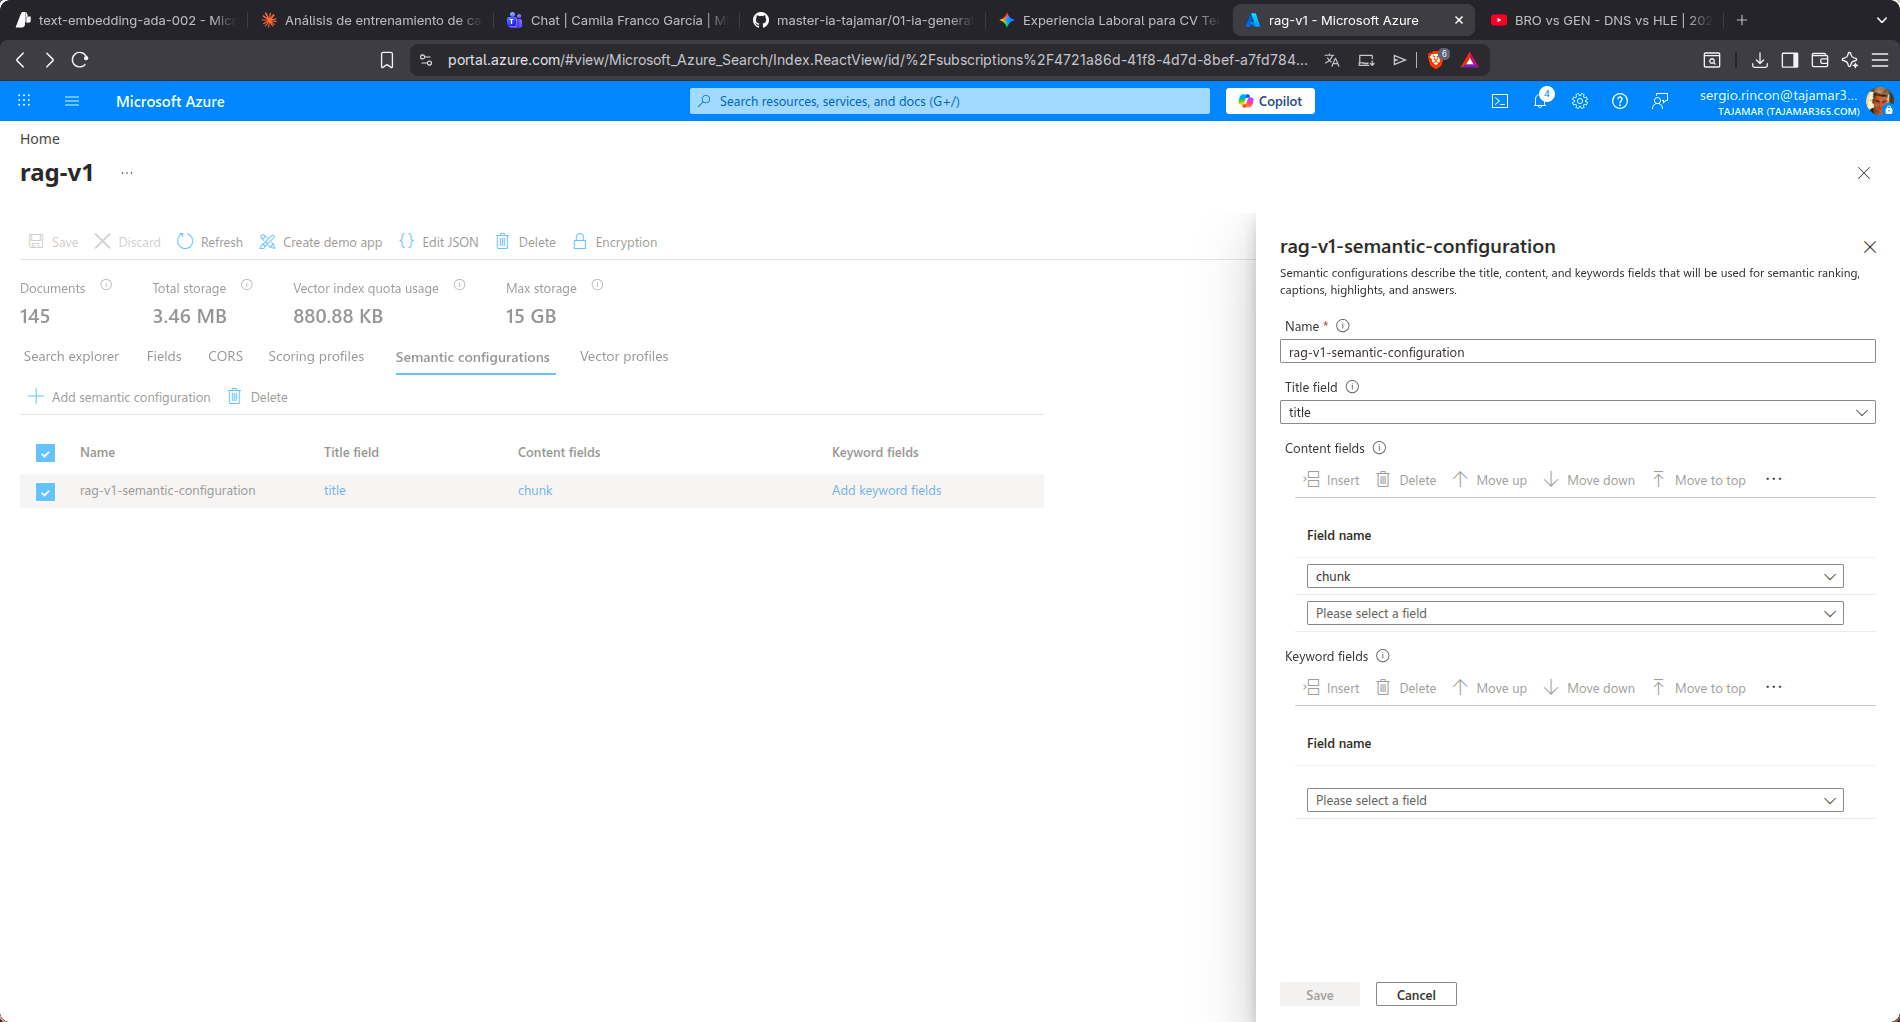

In [28]:

ruta_imagen_semantic = "./capturas/02_semantic_config.png" 

if os.path.exists(ruta_imagen_semantic):
    display(Image(filename=ruta_imagen_semantic))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen_semantic}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### ¿Qué es Semantic Configuration?

La configuración semántica permite realizar búsquedas semánticas usando modelos de lenguaje para entender la intención detrás de una consulta, no solo palabras clave.

**Componentes principales:**

1. **Title Field**: Campo que se usa como título en los resultados
   - Campo seleccionado: 
   - Propósito: Identificar el documento en los resultados

2. **Content Fields**: Campos donde buscar contenido semántico
   - Campos configurados:
     - chunk
   - Propósito: Azure Search realiza re-ranking semántico en estos campos

3. **Keywords Field**: Campo con palabras clave adicionales
   - Campo seleccionado: 
   - Propósito: Mejorar la precisión del ranking semántico

In [8]:

semantic_config = """
  "semantic": {
    "defaultConfiguration": "rag-v1-semantic-configuration",
    "configurations": [
      {
        "name": "rag-v1-semantic-configuration",
        "flightingOptIn": false,
        "rankingOrder": "BoostedRerankerScore",
        "prioritizedFields": {
          "titleField": {
            "fieldName": "title"
          },
          "prioritizedContentFields": [
            {
              "fieldName": "chunk"
            }
          ],
          "prioritizedKeywordsFields": []
        }
      }
    ]
  }
"""

print("📋 Configuración JSON de Semantic Configuration:")
print(semantic_config)

📋 Configuración JSON de Semantic Configuration:

  "semantic": {
    "defaultConfiguration": "rag-v1-semantic-configuration",
    "configurations": [
      {
        "name": "rag-v1-semantic-configuration",
        "flightingOptIn": false,
        "rankingOrder": "BoostedRerankerScore",
        "prioritizedFields": {
          "titleField": {
            "fieldName": "title"
          },
          "prioritizedContentFields": [
            {
              "fieldName": "chunk"
            }
          ],
          "prioritizedKeywordsFields": []
        }
      }
    ]
  }



### Ventajas de usar Semantic Search:
- ✅ Entiende el significado de la consulta, no solo coincidencias lexicales
- ✅ Re-ranking inteligente de resultados
- ✅ Mejor relevancia en búsquedas complejas
- ✅ Captions y answers automáticos en los resultados

---

## 4. VECTOR PROFILE

### Captura del Vector Profile (Algorithm y Vectorizer):

**Ruta de la imagen:** `./screenshots/03_vector_profile.png`

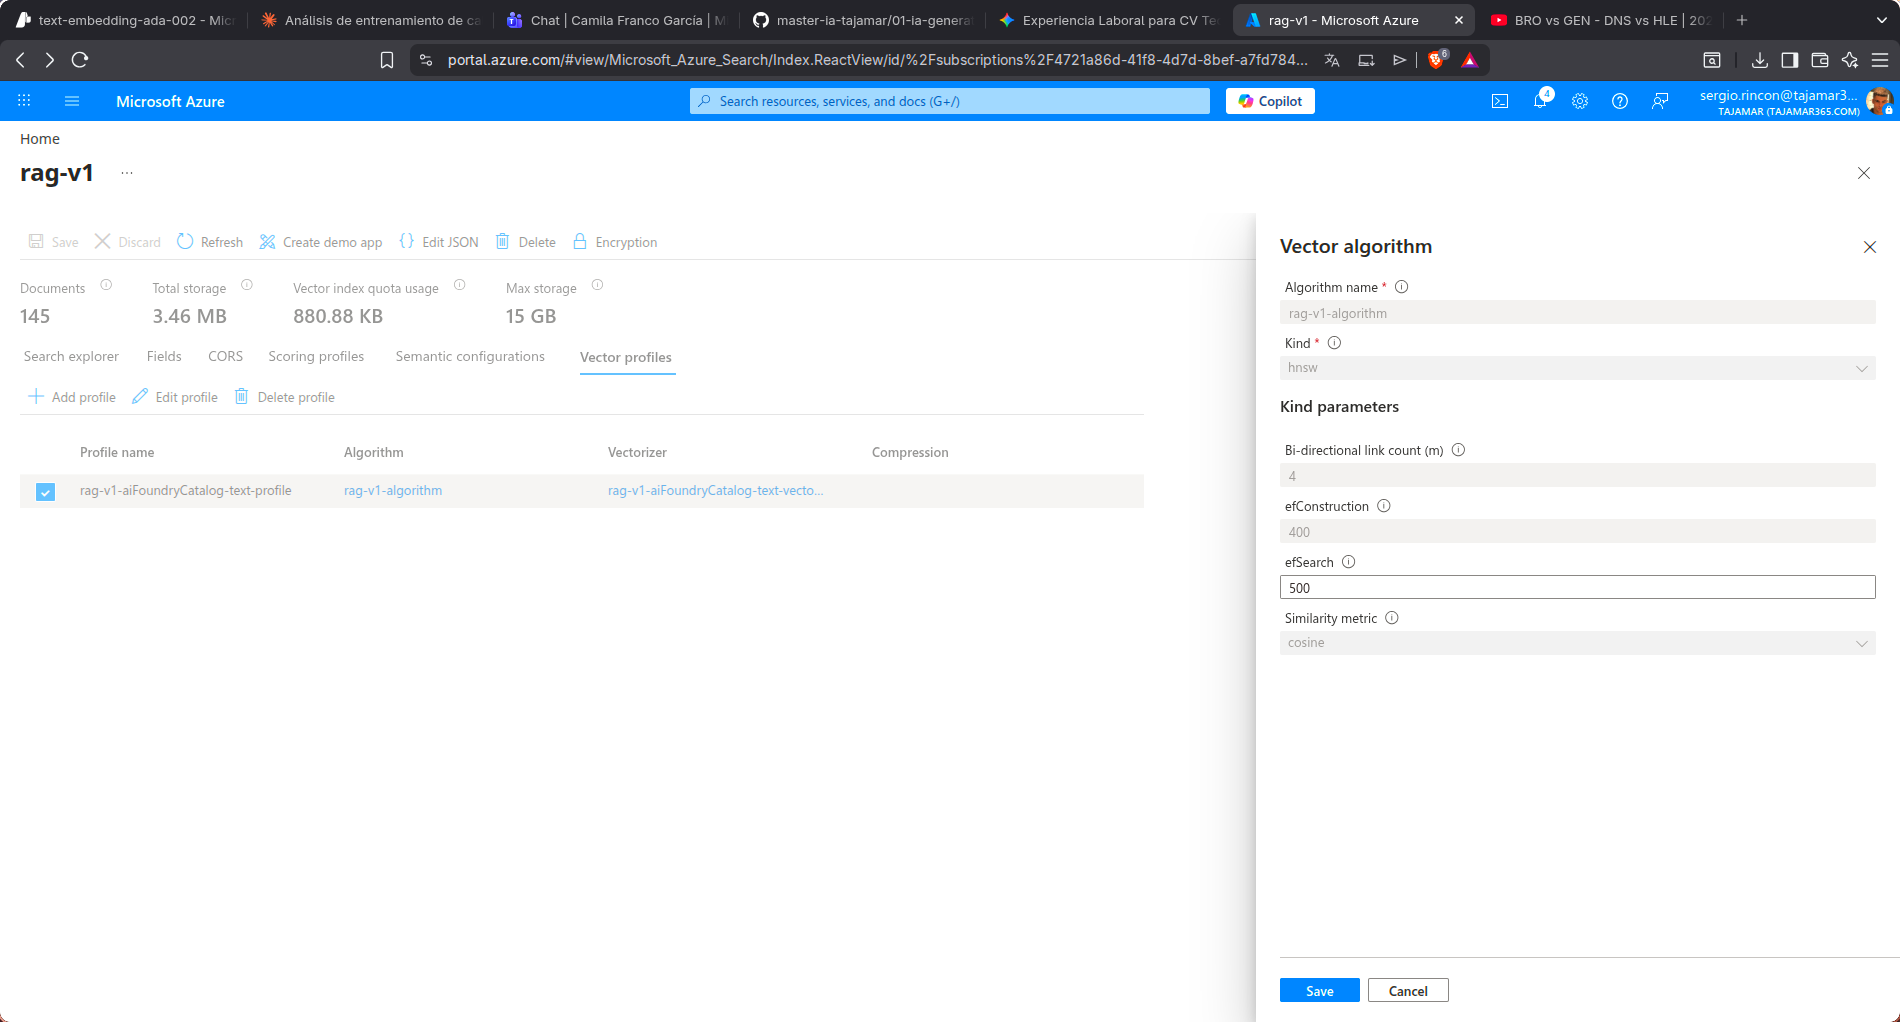

In [29]:


ruta_imagen_vector = "./capturas/03_vector_profile.png" 

if os.path.exists(ruta_imagen_vector):
    display(Image(filename=ruta_imagen_vector))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen_vector}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### 4.1 Vector Configuration

#### Algoritmo (Algorithm):

**Tipo de algoritmo utilizado:** `[HNSW]`

In [11]:
algorithm_config = """
"algorithms": [
      {
        "name": "rag-v1-algorithm",
        "kind": "hnsw",
        "hnswParameters": {
          "metric": "cosine",
          "m": 4,
          "efConstruction": 400,
          "efSearch": 500
        }
      }
    ],
"""

print("📋 Configuración del Algoritmo:")
print(algorithm_config)
print()
print("""📖 EXPLICACIÓN:
- **HNSW (Hierarchical Navigable Small World)**:
  * Algoritmo de búsqueda aproximada de vecinos más cercanos
  * m: Número de conexiones por nodo (default: 4)
  * efConstruction: Parámetro de construcción (default: 400)
  * efSearch: Parámetro de búsqueda (default: 500)
  * Ventaja: Muy rápido para búsquedas en índices grandes
  * Desventaja: Aproximado, no garantiza exactitud total

- **ExhaustiveKnn**:
  * Búsqueda exhaustiva (fuerza bruta)
  * Garantiza exactitud 100%
  * Más lento en índices grandes
  * Bueno para prototipos o índices pequeños
""")

📋 Configuración del Algoritmo:

"algorithms": [
      {
        "name": "rag-v1-algorithm",
        "kind": "hnsw",
        "hnswParameters": {
          "metric": "cosine",
          "m": 4,
          "efConstruction": 400,
          "efSearch": 500
        }
      }
    ],


📖 EXPLICACIÓN:
- **HNSW (Hierarchical Navigable Small World)**:
  * Algoritmo de búsqueda aproximada de vecinos más cercanos
  * m: Número de conexiones por nodo (default: 4)
  * efConstruction: Parámetro de construcción (default: 400)
  * efSearch: Parámetro de búsqueda (default: 500)
  * Ventaja: Muy rápido para búsquedas en índices grandes
  * Desventaja: Aproximado, no garantiza exactitud total

- **ExhaustiveKnn**:
  * Búsqueda exhaustiva (fuerza bruta)
  * Garantiza exactitud 100%
  * Más lento en índices grandes
  * Bueno para prototipos o índices pequeños



### 4.2 Vectorizer Configuration

**Tipo de vectorizador:** `[AzureOpenAI]`

In [17]:
vectorizer_config = """
"vectorizers": [
      {
        "name": "rag-v1-aiFoundryCatalog-text-vectorizer",
        "kind": "azureOpenAI",
        "azureOpenAIParameters": {
          "resourceUri": "https://ai-sergiorincon0872ai045504941434.openai.azure.com",
          "deploymentId": "text-embedding-ada-002",
          "apiKey": "<redacted>",
          "modelName": "text-embedding-ada-002"
        }
      }
    ],
    "compressions": []
  }
}
"""

print("📋 Configuración del Vectorizador:")
print(vectorizer_config)
print()
print("""📖 EXPLICACIÓN:
- **Azure OpenAI Vectorizer**:
  * Proveedor: Azure OpenAI Service
  * Modelo: text-embedding-3-large (u otro según configuración)
  * Dimensión de embeddings: 3072 (varía según modelo)
  * Autenticación: Managed Identity o API Key
  * Propósito: Convertir texto en vectores numéricos en tiempo de indexación y búsqueda

- **Parámetros clave:**
  * resourceUri: URL del recurso Azure OpenAI
  * deploymentId: ID del deployment de embeddings
  * modelName: Nombre del modelo (text-embedding-3-large)
  * Dimensions: Número de dimensiones del vector
""")

📋 Configuración del Vectorizador:

"vectorizers": [
      {
        "name": "rag-v1-aiFoundryCatalog-text-vectorizer",
        "kind": "azureOpenAI",
        "azureOpenAIParameters": {
          "resourceUri": "https://ai-sergiorincon0872ai045504941434.openai.azure.com",
          "deploymentId": "text-embedding-ada-002",
          "apiKey": "<redacted>",
          "modelName": "text-embedding-ada-002"
        }
      }
    ],
    "compressions": []
  }
}


📖 EXPLICACIÓN:
- **Azure OpenAI Vectorizer**:
  * Proveedor: Azure OpenAI Service
  * Modelo: text-embedding-3-large (u otro según configuración)
  * Dimensión de embeddings: 3072 (varía según modelo)
  * Autenticación: Managed Identity o API Key
  * Propósito: Convertir texto en vectores numéricos en tiempo de indexación y búsqueda

- **Parámetros clave:**
  * resourceUri: URL del recurso Azure OpenAI
  * deploymentId: ID del deployment de embeddings
  * modelName: Nombre del modelo (text-embedding-3-large)
  * Dimensions: Número d

### 4.3 Relación entre Algorithm y Vectorizer:

```
┌─────────────────────────────────┐
│  TEXTO (Documento o Query)      │
└────────────┬────────────────────┘
             │
             ▼
┌─────────────────────────────────┐
│  VECTORIZER (Azure OpenAI)      │
│  Convierte texto → vector 3072D │
└────────────┬────────────────────┘
             │
             ▼
┌─────────────────────────────────┐
│  VECTOR (3072 dimensiones)      │
└────────────┬────────────────────┘
             │
             ▼
┌─────────────────────────────────┐
│  ALGORITHM (HNSW)               │
│  Busca vecinos más cercanos     │
│  usando distancia euclidiana    │
└─────────────────────────────────┘
```

---

## 5. SKILLSET

### Captura del Skillset creado por el wizard:

**Ruta de la imagen:** `./screenshots/04_skillset.png`

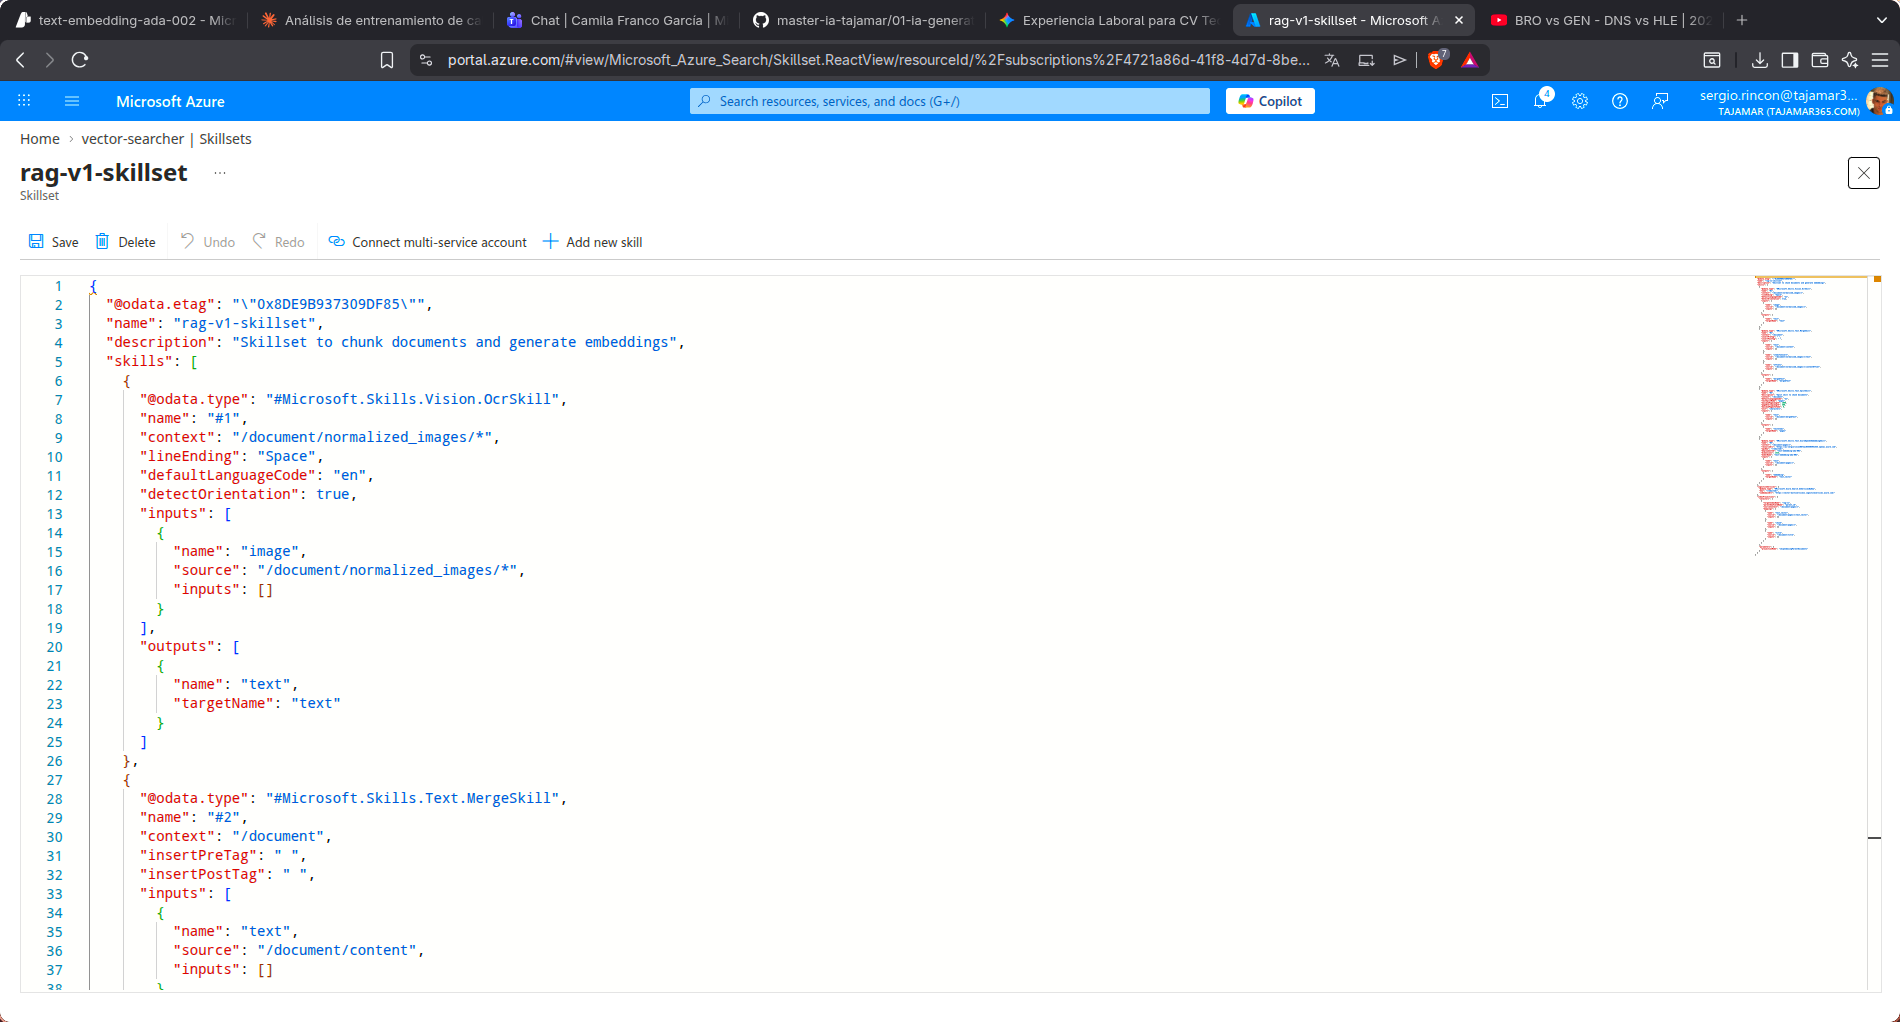

In [30]:

ruta_imagen_skillset = "./capturas/04_skillset.png" 

if os.path.exists(ruta_imagen_skillset):
    display(Image(filename=ruta_imagen_skillset))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen_skillset}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### ¿Qué es un Skillset?

Un Skillset es un conjunto de habilidades (skills) que se ejecutan durante la indexación para enriquecer los documentos con metadatos y transformaciones.

**Propósito:**
- Extraer información de documentos (OCR, entidades, etc.)
- Transformar contenido
- Generar embeddings (vectores)
- Crear campos adicionales para búsqueda mejorada

In [14]:

skillset_json = """
{
  "@odata.etag": "\"0x8DE9B937309DF85\"",
  "name": "rag-v1-skillset",
  "description": "Skillset to chunk documents and generate embeddings",
  "skills": [
    {
      "@odata.type": "#Microsoft.Skills.Vision.OcrSkill",
      "name": "#1",
      "context": "/document/normalized_images/*",
      "lineEnding": "Space",
      "defaultLanguageCode": "en",
      "detectOrientation": true,
      "inputs": [
        {
          "name": "image",
          "source": "/document/normalized_images/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "text",
          "targetName": "text"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.MergeSkill",
      "name": "#2",
      "context": "/document",
      "insertPreTag": " ",
      "insertPostTag": " ",
      "inputs": [
        {
          "name": "text",
          "source": "/document/content",
          "inputs": []
        },
        {
          "name": "itemsToInsert",
          "source": "/document/normalized_images/*/text",
          "inputs": []
        },
        {
          "name": "offsets",
          "source": "/document/normalized_images/*/contentOffset",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "mergedText",
          "targetName": "mergedText"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.SplitSkill",
      "name": "#3",
      "description": "Split skill to chunk documents",
      "context": "/document",
      "defaultLanguageCode": "en",
      "textSplitMode": "pages",
      "maximumPageLength": 2000,
      "pageOverlapLength": 500,
      "maximumPagesToTake": 0,
      "unit": "characters",
      "inputs": [
        {
          "name": "text",
          "source": "/document/mergedText",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "textItems",
          "targetName": "pages"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.AzureOpenAIEmbeddingSkill",
      "name": "#4",
      "context": "/document/pages/*",
      "resourceUri": "https://ai-sergiorincon0872ai045504941434.openai.azure.com",
      "apiKey": "<redacted>",
      "deploymentId": "text-embedding-ada-002",
      "dimensions": 1536,
      "modelName": "text-embedding-ada-002",
      "inputs": [
        {
          "name": "text",
          "source": "/document/pages/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "embedding",
          "targetName": "text_vector"
        }
      ]
    }
  ],
  "cognitiveServices": {
    "@odata.type": "#Microsoft.Azure.Search.AIServicesByKey",
    "key": "<redacted>",
    "subdomainUrl": "https://vector-multiservices1.cognitiveservices.azure.com/"
  },
  "indexProjections": {
    "selectors": [
      {
        "targetIndexName": "rag-v1",
        "parentKeyFieldName": "parent_id",
        "sourceContext": "/document/pages/*",
        "mappings": [
          {
            "name": "text_vector",
            "source": "/document/pages/*/text_vector",
            "inputs": []
          },
          {
            "name": "chunk",
            "source": "/document/pages/*",
            "inputs": []
          },
          {
            "name": "title",
            "source": "/document/title",
            "inputs": []
          }
        ]
      }
    ],
    "parameters": {
      "projectionMode": "skipIndexingParentDocuments"
    }
  }
}
"""

print("📋 Configuración JSON completa del Skillset:")
print(skillset_json)

📋 Configuración JSON completa del Skillset:

{
  "@odata.etag": ""0x8DE9B937309DF85"",
  "name": "rag-v1-skillset",
  "description": "Skillset to chunk documents and generate embeddings",
  "skills": [
    {
      "@odata.type": "#Microsoft.Skills.Vision.OcrSkill",
      "name": "#1",
      "context": "/document/normalized_images/*",
      "lineEnding": "Space",
      "defaultLanguageCode": "en",
      "detectOrientation": true,
      "inputs": [
        {
          "name": "image",
          "source": "/document/normalized_images/*",
          "inputs": []
        }
      ],
      "outputs": [
        {
          "name": "text",
          "targetName": "text"
        }
      ]
    },
    {
      "@odata.type": "#Microsoft.Skills.Text.MergeSkill",
      "name": "#2",
      "context": "/document",
      "insertPreTag": " ",
      "insertPostTag": " ",
      "inputs": [
        {
          "name": "text",
          "source": "/document/content",
          "inputs": []
        },
        

### Pipeline de ejecución del Skillset:

```
1. Documento → Azure Blob Storage
                   │
                   ▼
2. Data Source (Connección)
                   │
                   ▼
3. Text Extraction Skill
                   │
                   ▼
4. Azure OpenAI Embedding Skill
   (Genera embeddings)
                   │
                   ▼
5. Indexer (Inserta en el índice)
                   │
                   ▼
6. Índice con campos vectoriales
```

---

## 6. INDEXER

### Captura del Indexer creado:

**Ruta de la imagen:** `./screenshots/05_indexer.png`

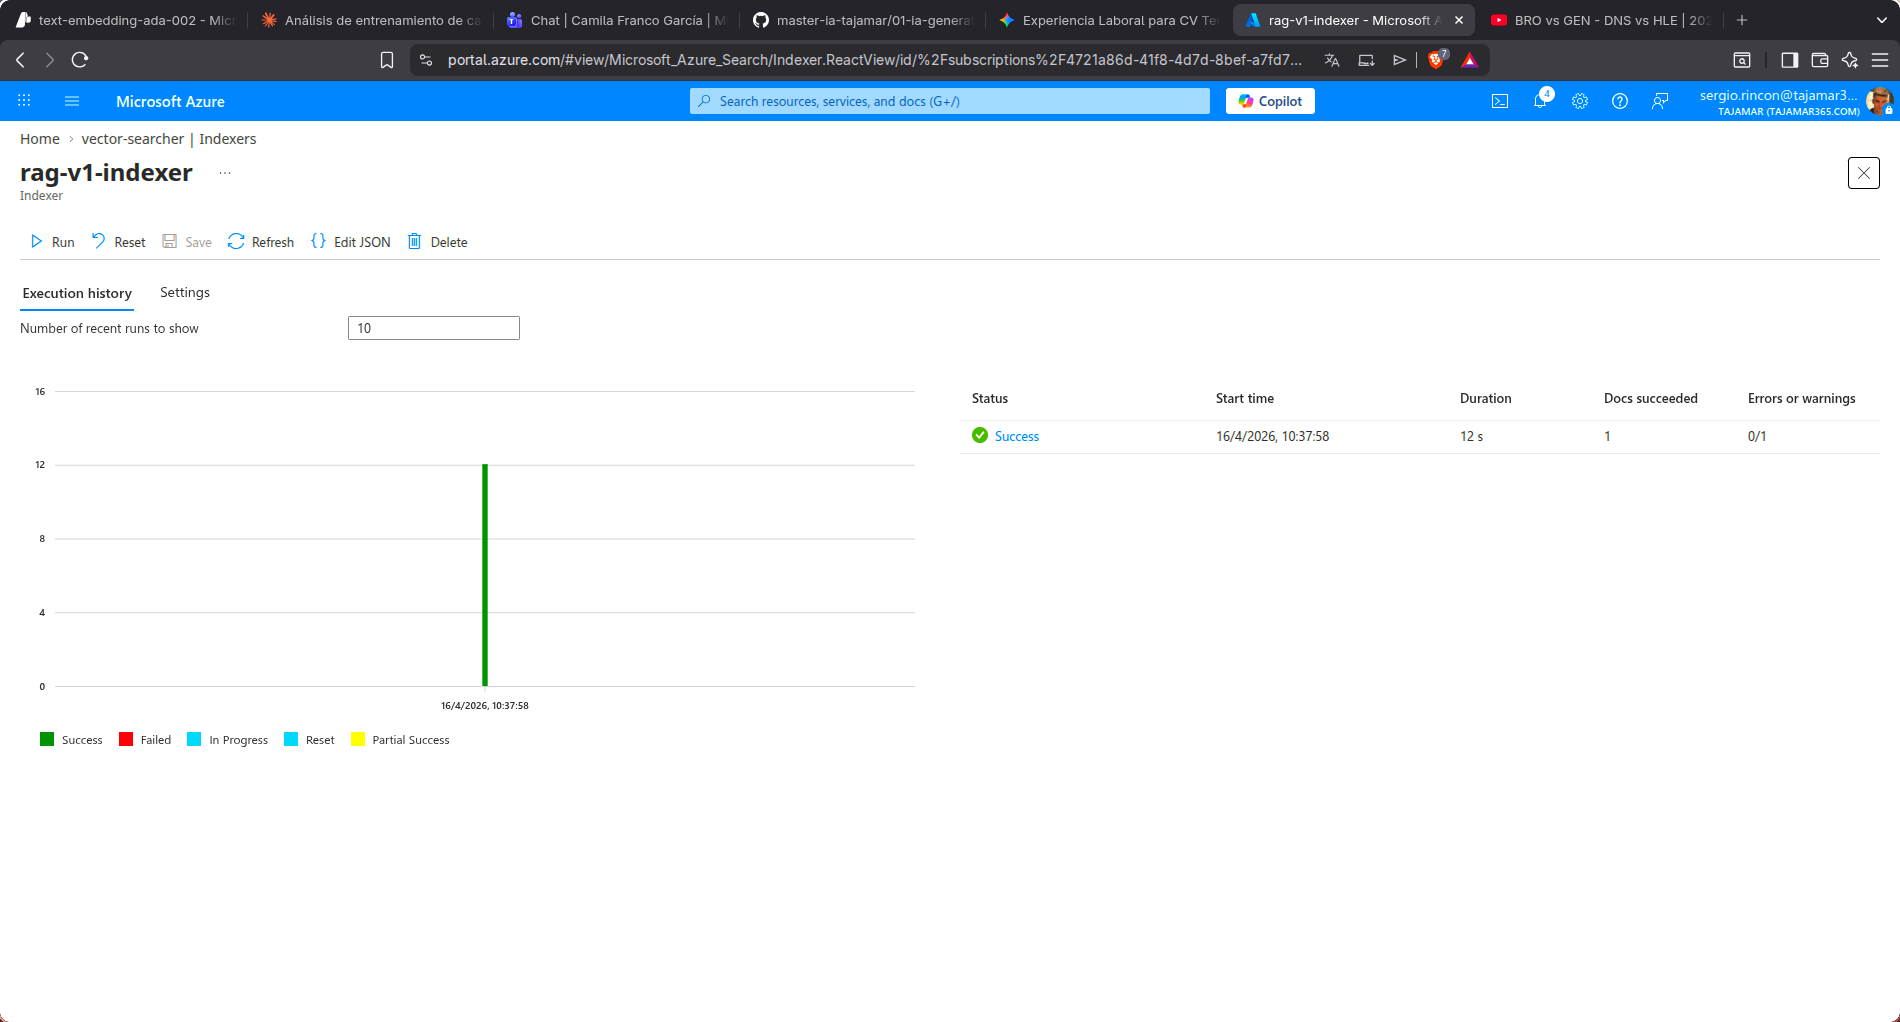

In [31]:

ruta_imagen_indexer = "./capturas/05_indexer.png" 

if os.path.exists(ruta_imagen_indexer):
    display(Image(filename=ruta_imagen_indexer))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen_indexer}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### Configuración del Indexer:

**Nombre:** `[rag-v1-indexer]`

In [18]:

indexer_json = """
{
  "@odata.context": "https://vector-searcher.search.windows.net/$metadata#indexers/$entity",
  "@odata.etag": "\"0x8DE9B937DE8D876\"",
  "name": "rag-v1-indexer",
  "description": null,
  "dataSourceName": "rag-v1-datasource",
  "skillsetName": "rag-v1-skillset",
  "targetIndexName": "rag-v1",
  "disabled": null,
  "schedule": null,
  "parameters": {
    "batchSize": null,
    "maxFailedItems": null,
    "maxFailedItemsPerBatch": null,
    "configuration": {
      "imageAction": "generateNormalizedImages",
      "parsingMode": "default"
    }
  },
  "fieldMappings": [
    {
      "sourceFieldName": "metadata_storage_name",
      "targetFieldName": "title",
      "mappingFunction": null
    }
  ],
  "outputFieldMappings": [],
  "cache": null,
  "encryptionKey": null
}
"""

print("📋 Configuración JSON del Indexer:")
print(indexer_json)

📋 Configuración JSON del Indexer:

{
  "@odata.context": "https://vector-searcher.search.windows.net/$metadata#indexers/$entity",
  "@odata.etag": ""0x8DE9B937DE8D876"",
  "name": "rag-v1-indexer",
  "description": null,
  "dataSourceName": "rag-v1-datasource",
  "skillsetName": "rag-v1-skillset",
  "targetIndexName": "rag-v1",
  "disabled": null,
  "schedule": null,
  "parameters": {
    "batchSize": null,
    "maxFailedItems": null,
    "maxFailedItemsPerBatch": null,
    "configuration": {
      "imageAction": "generateNormalizedImages",
      "parsingMode": "default"
    }
  },
  "fieldMappings": [
    {
      "sourceFieldName": "metadata_storage_name",
      "targetFieldName": "title",
      "mappingFunction": null
    }
  ],
  "outputFieldMappings": [],
  "cache": null,
  "encryptionKey": null
}



## 7. DATA SOURCE

### Captura de la Data Source:

**Ruta de la imagen:** `./capturas/06_data_source.png`

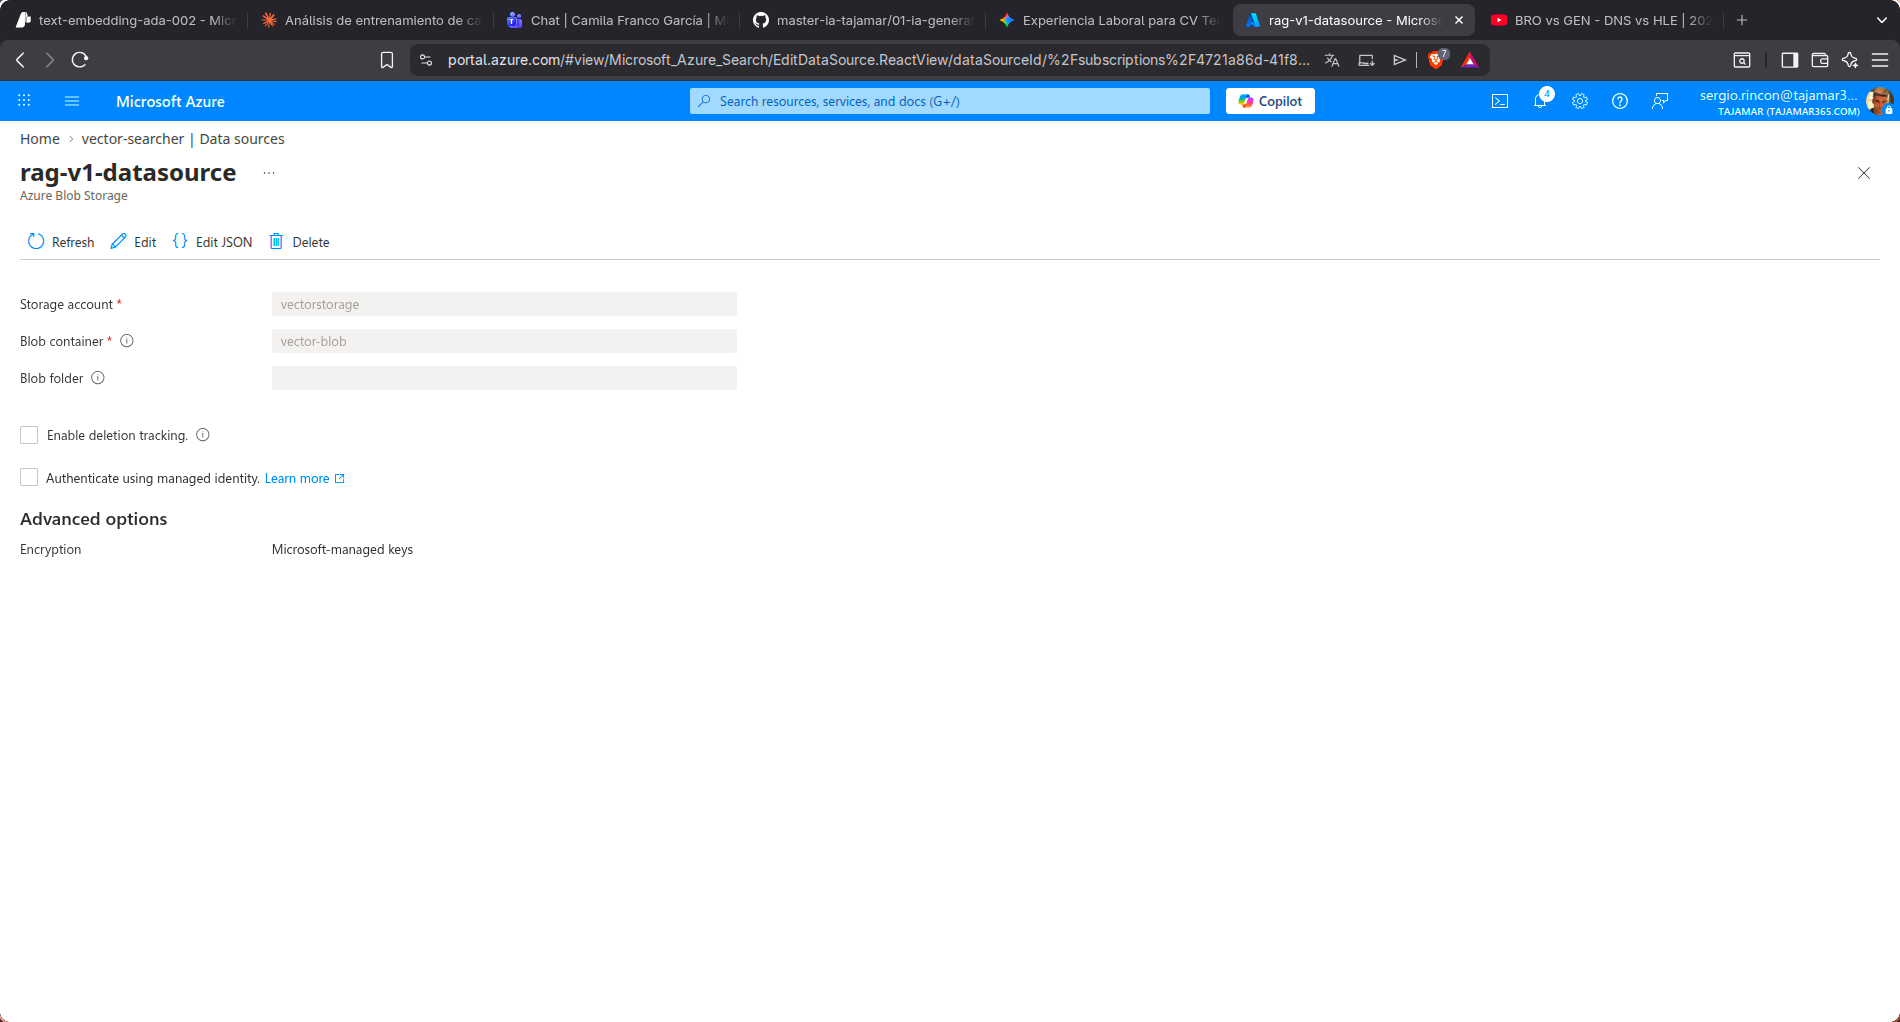

In [32]:
ruta_imagen_datasource = "./capturas/06_data_source.png" 

if os.path.exists(ruta_imagen_datasource):
    display(Image(filename=ruta_imagen_datasource))
else:
    print(f"❌ No se encontró la imagen en: {ruta_imagen_datasource}")
    print(f"   Asegúrate de colocar la imagen en la ruta indicada")

### Configuración de Data Source:

La Data Source es la conexión a Azure Blob Storage que especifica dónde están los documentos a indexar.

In [20]:
datasource_json = """
{
  "@odata.context": "https://vector-searcher.search.windows.net/$metadata#datasources/$entity",
  "@odata.etag": "\"0x8DE9B937124EA12\"",
  "name": "rag-v1-datasource",
  "description": null,
  "type": "azureblob",
  "subtype": null,
  "indexerPermissionOptions": [],
  "credentials": {
    "connectionString": "DefaultEndpointsProtocol=https;AccountName=vectorstorage;AccountKey=..."
  },
  "container": {
    "name": "vector-blob",
    "query": null
  },
  "dataChangeDetectionPolicy": null,
  "dataDeletionDetectionPolicy": null,
  "encryptionKey": null,
  "identity": null
}
"""

print("📋 Configuración JSON de Data Source:")
print(datasource_json)

📋 Configuración JSON de Data Source:

{
  "@odata.context": "https://vector-searcher.search.windows.net/$metadata#datasources/$entity",
  "@odata.etag": ""0x8DE9B937124EA12"",
  "name": "rag-v1-datasource",
  "description": null,
  "type": "azureblob",
  "subtype": null,
  "indexerPermissionOptions": [],
  "credentials": {
    "connectionString": "DefaultEndpointsProtocol=https;AccountName=vectorstorage;AccountKey=..."
  },
  "container": {
    "name": "vector-blob",
    "query": null
  },
  "dataChangeDetectionPolicy": null,
  "dataDeletionDetectionPolicy": null,
  "encryptionKey": null,
  "identity": null
}



---
## 8. RESUMEN Y CONCLUSIONES

### Arquitectura completa implementada:

```
┌──────────────────────────────┐
│   Azure Blob Storage         │
│   (Contenedor con documentos)│
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   Data Source (Conexión)     │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   Indexer (Orquestador)      │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   Skillset (Enriquecimiento) │
│  - Text Extraction           │
│  - Embeddings (Azure OpenAI) │
└──────────────┬───────────────┘
               │
               ▼
┌──────────────────────────────┐
│   Índice (con vectores)      │
│  - Campos de texto           │
│  - Campos vectoriales        │
│  - Semantic Config           │
└──────────────────────────────┘
```

In [26]:


resumen_datos = {
    "Total de documentos": "[1]",
    "Total de chunks/embeddings": "[0]",
    "Tamaño del índice": "[15GB]",
    "Campos vectoriales": "3072 dimensiones",
    "Modelo de embeddings": "text-adda-embedding-2",
    "Algoritmo de búsqueda": "HNSW",
    "Distancia": "Euclidean"
}

print("📊 RESUMEN DE INDEXACIÓN")
print("=" * 50)
for clave, valor in resumen_datos.items():
    print(f"{clave:.<30} {valor}")

📊 RESUMEN DE INDEXACIÓN
Total de documentos........... [1]
Total de chunks/embeddings.... [0]
Tamaño del índice............. [15GB]
Campos vectoriales............ 3072 dimensiones
Modelo de embeddings.......... text-adda-embedding-2
Algoritmo de búsqueda......... HNSW
Distancia..................... Euclidean


### Próximos pasos (Parte 2):
- Ejecutar Vector Search
- Ejecutar Hybrid Search
- Ejecutar Semantic Search
- Ejecutar Semantic Hybrid Search

---

## 9. Notas y observaciones

**[Escribe aquí cualquier observación, problema encontrado o nota sobre la configuración]**

---

In [33]:


archivos_esperados = [
    "./capturas/01_index_schema.png",
    "./capturas/02_semantic_config.png",
    "./capturas/03_vector_profile.png",
    "./capturas/04_skillset.png",
    "./capturas/05_indexer.png",
    "./capturas/06_data_source.png"
]

print("✅ VERIFICACIÓN DE ARCHIVOS")
print("=" * 50)
for archivo in archivos_esperados:
    if os.path.exists(archivo):
        print(f"✓ {archivo}")
    else:
        print(f"✗ {archivo} - NO ENCONTRADO")


✅ VERIFICACIÓN DE ARCHIVOS
✓ ./capturas/01_index_schema.png
✓ ./capturas/02_semantic_config.png
✓ ./capturas/03_vector_profile.png
✓ ./capturas/04_skillset.png
✓ ./capturas/05_indexer.png
✓ ./capturas/06_data_source.png
